# Digit Recognizer

**Task**  
Learn computer vision fundamentals with the famous MNIST data.

**Columns:**
- Pixel(0 ~ 783)
- Label 0 ~ 9 (Only train.csv have)

**Link to dataset:**  
https://www.kaggle.com/competitions/digit-recognizer/data

**Code is referenced from @KASSEM**

### Import Package

In [1]:
! pip3 install keras.utils

DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Dropout, Flatten,Conv2D, Lambda, MaxPooling2D, BatchNormalization
from sklearn.model_selection import train_test_split

In [26]:
train_ds = pd.read_csv('dataset/train.csv')
test_ds  = pd.read_csv('dataset/test.csv')
submission = pd.read_csv('dataset/sample_submission.csv')

In [4]:
print(f"Training dataset size is {train_ds.shape}\nTesting dataset size is {test_ds.shape}")

Training dataset size is (42000, 785)
Testing dataset size is (28000, 784)


In [5]:
X = train_ds.drop(['label'], 1).values
y = train_ds['label'].values

/var/folders/9_/wthl_cxn5hgc_743_j_5q2cw0000gn/T/ipykernel_75223/3177717387.py:1: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  X = train_ds.drop(['label'], 1).values


In [6]:
# Normalization
X = X / 255.0
# Reshape
X = X.reshape(-1, 28, 28, 1)
# Label encoding -> One-Hot Encoding(ex: 1 -> [0, 1, 0, 0, 0, 0, 0, 0, 0, 0])
y = to_categorical(y)

print(f"Label size is {y.shape}")

Label size is (42000, 10)


In [7]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.1, random_state = 0)

print(f"Training dataset size is {X_train.shape}\nEvaluation dataset size is {X_val.shape}")
print(f"Training label size is {y_train.shape}\nEvaluation label size is {y_val.shape}")

Training dataset size is (37800, 28, 28, 1)
Evaluation dataset size is (4200, 28, 28, 1)
Training label size is (37800, 10)
Evaluation label size is (4200, 10)


In [8]:
# Normalization
mean = np.mean(X_train)
std = np.std(X_train)

def standardiza(x):
    return (x - mean)/std

### Build Model

In [9]:
model = Sequential()
model.add(Conv2D(filters=64, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)))
model.add(Conv2D(filters=64, kernel_size=(3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Conv2D(filters=128, kernel_size=(3,3), activation="relu"))
model.add(Conv2D(filters=128, kernel_size=(3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Conv2D(filters=256, kernel_size=(3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Flatten())
model.add(Dense(512,activation="relu"))
model.add(Dense(10,activation="softmax"))

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 64)        640       
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 64)        36928     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 12, 12, 64)       0         


2022-06-12 11:39:58.549913: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


 )                                                               
                                                                 
 batch_normalization (BatchN  (None, 12, 12, 64)       256       
 ormalization)                                                   
                                                                 
 conv2d_2 (Conv2D)           (None, 10, 10, 128)       73856     
                                                                 
 conv2d_3 (Conv2D)           (None, 8, 8, 128)         147584    
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 4, 4, 128)        0         
 2D)                                                             
                                                                 
 batch_normalization_1 (Batc  (None, 4, 4, 128)        512       
 hNormalization)                                                 
                                                                 
 conv2d_4 

### Data Augmentation

In [10]:
dataGen = ImageDataGenerator(
    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    samplewise_std_normalization=False,
    zca_whitening=False,
    rotation_range=15,
    zoom_range=0.01,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False,
    vertical_flip=False
)

train_gen = dataGen.flow(X_train, y_train, batch_size=128)
val_gen = dataGen.flow(X_val, y_val, batch_size=128)

### Train Model

In [11]:
epochs = 100
batch_size = 128
train_step = X_train.shape[0] // batch_size
val_step = X_val.shape[0] // batch_size

es = EarlyStopping(
    monitor="val_acc",
    patience=10,
    verbose=1,
    mode="max",
    restore_best_weights=True
)

rp = ReduceLROnPlateau(
    monitor="val_acc",
    factor=0.2,
    patience=3,
    verbose=1,
    mode="max",
    min_lr=0.00001
)

In [12]:
history = model.fit_generator(
    train_gen,
    epochs = epochs,
    steps_per_epoch=train_step,
    validation_data=val_gen,
    validation_steps=val_step,
    callbacks=[es, rp]
)

Epoch 1/100


/var/folders/9_/wthl_cxn5hgc_743_j_5q2cw0000gn/T/ipykernel_75223/2195965365.py:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(


295/295 [==============================] - 103s 345ms/step - loss: 0.1565 - accuracy: 0.9494 - val_loss: 1.7683 - val_accuracy: 0.3010 - lr: 0.0010
Epoch 2/100
295/295 [==============================] - 108s 365ms/step - loss: 0.0656 - accuracy: 0.9793 - val_loss: 0.0780 - val_accuracy: 0.9768 - lr: 0.0010
Epoch 3/100
295/295 [==============================] - 98s 332ms/step - loss: 0.0477 - accuracy: 0.9856 - val_loss: 0.0712 - val_accuracy: 0.9761 - lr: 0.0010
Epoch 4/100
295/295 [==============================] - 70s 238ms/step - loss: 0.0435 - accuracy: 0.9861 - val_loss: 0.0542 - val_accuracy: 0.9827 - lr: 0.0010
Epoch 5/100
295/295 [==============================] - 71s 240ms/step - loss: 0.0389 - accuracy: 0.9880 - val_loss: 0.0418 - val_accuracy: 0.9875 - lr: 0.0010
Epoch 6/100
295/295 [==============================] - 89s 303ms/step - loss: 0.0362 - accuracy: 0.9897 - val_loss: 0.0395 - val_accuracy: 0.9868 - lr: 0.0010
Epoch 7/100
295/295 [==============================] - 1

### Evaluate Model

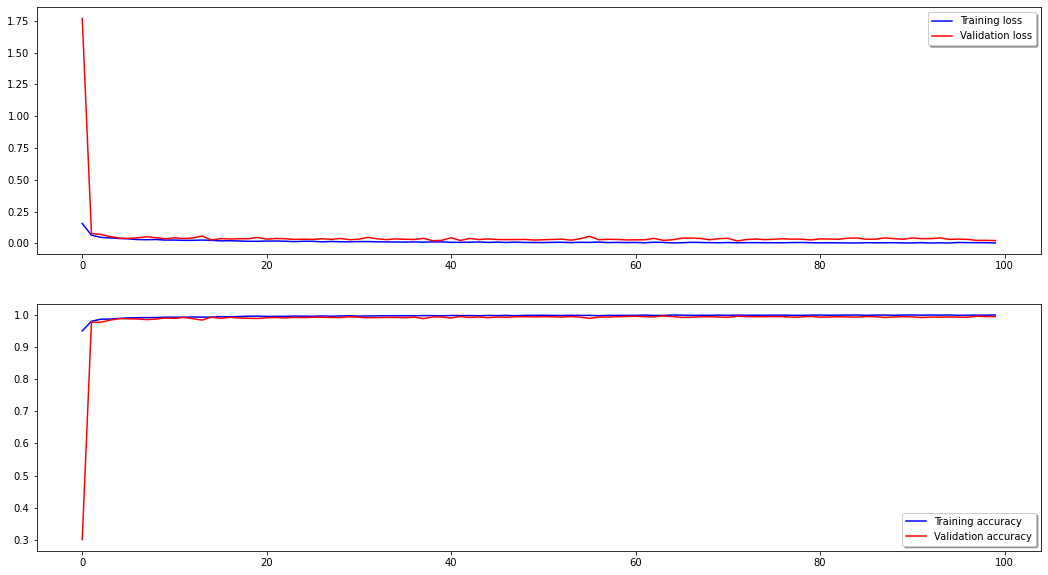

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(18, 10))
ax[0].plot(history.history['loss'], color='b', label="Training loss")
ax[0].plot(history.history['val_loss'], color='r', label="Validation loss", axes = ax[0])
legend = ax[0].legend(loc='best', shadow=True)

ax[1].plot(history.history['accuracy'], color='b', label="Training accuracy")
ax[1].plot(history.history['val_accuracy'], color='r', label="Validation accuracy")
legend = ax[1].legend(loc='best', shadow=True)

### Make Submission

In [27]:
test_ds = test_ds.values
test_ds = test_ds / 255.0
test_ds = test_ds.reshape(-1, 28, 28, 1)

y_pro = model.predict(test_ds)
y_sub = np.argmax(y_pro, axis = 1)

In [28]:
submission['Label'] = y_sub
submission.to_csv("Submission.csv", index=False)
submission

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3
...,...,...
27995,27996,9
27996,27997,7
27997,27998,3
27998,27999,9
